# **Libraries**

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import math
from matplotlib import colors
from matplotlib.colors import LogNorm
import seaborn as sns
import matplotlib.lines as mlines
pd.options.mode.chained_assignment = None
pd.set_option('display.max_columns', None)

# Useful functions 

# Function to parse size class ranges
def parse_size_class(size_class_str):
    if '-' in size_class_str:
        return list(map(float, size_class_str.replace(' ', '').split('-')))
    else:
        return [float(size_class_str.strip()), float(size_class_str.strip())]

# Function to assign a size class
def assign_size_class(esd_um):
    for i, (low, high) in enumerate(size_class_ranges):
        if low <= esd_um <= high:
            return size_class['size_classes'][i].replace(' ', '')  # Remove extra spaces
    return None


# **Import tracks data for APERO cruise**

In [3]:
# APERO 
APERO = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/APERO_selected_tracks_by_interquartile_poly_no_living.csv')
APERO['cruise'] = 'APERO'
APERO['zone'] = 'North Atlantic'
APERO_tracks = APERO.drop(columns=['Unnamed: 0'])
APERO_tracks

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone
0,-47.997545,20230611-002733,APERO_C1_20230611-002816-1-916,27.067691,246.547642,63.023866,25.400000,75.065237,1293.285094,35.962273,0.556984,12.525483,48538.074003,246.547642,6.792744,2.980531,1.851820,26.766581,42.501572,923.600000,60.200000,25.600000,114.200000,88.600000,17.600000,0.889301,0.570833,0.827087,695,75.065237,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
1,-47.035952,20230611-002733,APERO_C1_20230611-002829-1-1435,31.555337,1035.906803,104.796561,42.428571,78.591289,1293.285094,35.962273,0.556984,55.320601,859557.536536,1035.906803,19.853928,11.867176,2.787027,53.461416,51.070820,19810.642857,100.250000,23.071429,223.785714,200.714286,201.928571,0.802409,0.672769,0.899479,695,78.591289,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
2,-46.920249,20230611-002733,APERO_C1_20230611-002834-1-1578,51.631967,108.968921,55.305556,44.000000,98.552216,1293.285094,35.962273,0.556984,3.475353,9388.330656,108.968921,2.370224,1.451709,1.539296,19.318232,35.143488,190.888889,52.333333,33.777778,81.111111,47.333333,3.444444,0.561840,0.851852,1.000000,695,98.552216,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
3,-41.519202,20230611-002733,APERO_C1_20230611-002907-2-2931,40.011558,136.415389,73.325735,89.970588,81.530760,1293.285094,35.962273,0.556984,5.232517,14976.206705,136.415389,2.906261,2.001715,1.809873,28.821153,39.807768,385.529412,70.779412,36.352941,114.441176,78.088235,5.294118,0.581690,0.853758,0.981338,695,81.530760,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
4,-40.571366,20230611-002733,APERO_C1_20230611-002918-1-3368,48.514431,124.092221,72.480258,95.708333,89.085797,1293.285094,35.962273,0.556984,4.511845,12366.940032,124.092221,2.437109,1.912335,1.863164,28.867687,40.780294,319.833333,70.270833,37.750000,114.166667,76.416667,4.375000,0.360660,0.868056,1.000000,695,89.085797,-19.573616,17.995637,74.349515,-75.927494,not-living,APERO,North Atlantic
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
791,86.862360,20230713-042803,APERO_C5_20230713-043248-1-8413,149.314402,859.596554,81.899763,261.384615,62.452042,569.800296,23.870490,0.887168,72.414924,582002.226297,859.596554,24.930501,10.582206,2.904711,36.067138,43.897118,10766.538462,81.923077,23.230769,167.615385,144.384615,217.307692,0.904952,0.410473,0.600251,551,62.452042,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
792,94.602154,20230713-042803,APERO_C5_20230713-043301-1-8717,169.000999,239.397542,53.623205,274.000000,74.398845,569.800296,23.870490,0.887168,12.866225,50557.019943,239.397542,7.284838,2.913288,1.671898,33.266155,60.209407,832.846154,42.307692,24.769231,144.307692,119.538462,19.846154,0.859600,0.539977,0.786790,551,74.398845,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
793,106.876513,20230713-042803,APERO_C5_20230713-043322-1-9208,171.007026,402.057780,91.429246,294.500000,64.130513,569.800296,23.870490,0.887168,21.368446,127511.038493,402.057780,8.258849,5.591207,2.588733,43.980739,48.059479,3149.083333,91.125000,24.500000,176.166667,151.666667,38.583333,0.732405,0.655357,0.888611,551,64.130513,-14.625216,13.453793,55.572305,-56.743728,not-living,APERO,North Atlantic
794,144.642565,20230713-042803,APERO_C5_20230713-043431-1-11126,84.461913,165.521745,39.600017,362.000000,-60.180652,569.800296,23.870490,0.887168,7.230796,22799.832971,165.521745,4.296724,2.222534,1.708472,14.111826,34.045029,315.222222,37.000000,23.888889,64.555556,40.666667,9.000

# **Import UVP6 size classes**

In [4]:
size_class = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/size_classes.csv', delimiter = ';')

In [5]:
# add size classes
size_class_ranges = [parse_size_class(sc) for sc in size_class['size_classes']]
APERO_tracks['size_classes'] = APERO_tracks['esd_um'].apply(assign_size_class)
APERO_tracks = APERO_tracks.sort_values(by='esd_um')
APERO_tracks['size_classes'].unique()

array(['80.6-102', '102-128', '128-161', '161-203', '203-256', '256-323',
       '323-406', '406-512', '512-645', '645-813', '813-1020',
       '1020-1290', '1290-1630', '1630-2050', '2050-2580', '3250-4100',
       '5160-6500'], dtype=object)

In [6]:
desc = APERO_tracks[APERO_tracks['corrected_by_poly'] >= 0]
desc = desc.sort_values(by='esd_um')
asc = APERO_tracks[APERO_tracks['corrected_by_poly'] < 0]
asc = asc.sort_values(by='esd_um')

# **Compute the number of particles for each size class for ascending and descending categories**

In [7]:
# for descending ones 
nb_part_desc = desc.groupby('size_classes').size().reset_index(name='desc_count')
nb_part_desc['lower_bound'] = nb_part_desc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_desc = nb_part_desc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_desc

,size_classes,desc_count
15,80.6-102,4
0,102-128,96
2,128-161,73
4,161-203,56
6,203-256,46
8,256-323,61
9,323-406,36
11,406-512,29
12,512-645,32
14,645-813,22


In [8]:
# for ascending ones 
nb_part_asc = asc.groupby('size_classes').size().reset_index(name='asc_count')
nb_part_asc['lower_bound'] = nb_part_asc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_asc = nb_part_asc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_asc

,size_classes,asc_count
11,80.6-102,3
0,102-128,72
2,128-161,55
3,161-203,57
4,203-256,43
6,256-323,36
7,323-406,24
8,406-512,12
9,512-645,1
10,645-813,2


In [9]:
nb_part_tot_APERO = pd.merge(nb_part_desc, nb_part_asc, on = 'size_classes')
nb_part_tot_APERO

,size_classes,desc_count,asc_count
0,80.6-102,4,3
1,102-128,96,72
2,128-161,73,55
3,161-203,56,57
4,203-256,46,43
5,256-323,61,36
6,323-406,36,24
7,406-512,29,12
8,512-645,32,1
9,645-813,22,2


# **Do the same for Vlfr tracks**

In [10]:
# Vlfr 
VLFR_tracks = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/VLFR_selected_tracks_by_interquartile_poly_no_living.csv')
VLFR_tracks['cruise'] = 'vlfr'
VLFR_tracks['zone'] = 'Mediterranean Sea'
VLFR_tracks

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone
0,167.671521,20230418-142321,vlfr_20230418-142403-1-418,94.296297,114.971982,54.343333,22.000000,-73.375225,660.192273,25.694207,0.588969,4.214214,10511.082352,114.971982,2.756337,1.484728,1.527067,17.261139,35.035069,200.000000,52.900000,34.800000,76.800000,42.000000,3.800000,0.832847,0.733333,1.000000,152,-73.375225,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
1,166.317665,20230418-142321,vlfr_20230418-142413-1-608,258.038728,455.286457,99.981881,39.500000,91.721063,660.192273,25.694207,0.588969,23.780866,165885.520336,455.286457,8.798337,6.359408,2.686349,54.308297,54.193766,4319.650000,95.875000,24.300000,196.950000,172.650000,48.850000,0.685007,0.689685,0.893653,152,91.721063,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
2,164.584620,20230418-142321,vlfr_20230418-142426-1-958,228.438677,304.382251,74.276076,57.500000,63.854057,660.192273,25.694207,0.588969,16.454892,73172.536294,304.382251,7.618501,3.825806,2.162067,32.602755,43.467906,1573.900000,72.466667,25.266667,131.800000,106.533333,25.100000,0.859971,0.658710,0.838654,152,63.854057,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
3,158.741302,20230418-142321,vlfr_20230418-142511-1-2256,236.135415,363.951173,97.182311,102.500000,77.394113,660.192273,25.694207,0.588969,18.018411,106376.804184,363.951173,7.179743,5.181784,2.494909,47.257284,48.446262,2902.100000,96.866667,25.066667,176.000000,150.933333,31.266667,0.683738,0.759087,0.929594,152,77.394113,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
4,147.674681,20230418-142321,vlfr_20230418-142605-1-3707,215.745130,496.847746,89.540776,162.125000,68.070449,660.192273,25.694207,0.588969,26.180282,196658.316651,496.847746,9.056392,7.349353,2.880501,35.182899,39.581544,4487.925000,93.787500,25.275000,156.850000,131.575000,56.775000,0.565832,0.708847,0.880709,152,68.070449,-16.536293,13.132384,57.635401,-61.039310,detritus,vlfr,Mediterranean Sea
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
461,-84.057856,20230501-231319,vlfr_20230501-231957-1-10371,-140.192296,195.102155,73.021077,376.500000,-56.134440,378.987625,19.467604,0.615935,8.781092,30191.027904,195.102155,4.147502,2.918092,2.116595,33.204497,44.742046,709.375000,68.375000,27.875000,129.875000,102.000000,10.000000,0.682493,0.785764,0.963542,409,-56.134440,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
462,-85.285975,20230501-231319,vlfr_20230501-232003-1-10572,-154.435880,205.712784,68.098055,383.444444,-69.149905,378.987625,19.467604,0.615935,9.418162,33517.908728,205.712784,5.373178,2.573705,1.754223,29.566250,43.793047,718.666667,64.611111,28.333333,123.444444,95.111111,12.000000,0.873998,0.737037,0.879361,409,-69.149905,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
463,-85.481231,20230501-231319,vlfr_20230501-232004-1-10588,-141.559343,191.745555,88.308025,384.555556,-56.078112,378.987625,19.467604,0.615935,8.694304,29664.313902,191.745555,4.250962,2.686470,2.037128,47.433904,54.196583,832.444444,84.055556,27.111111,170.111111,143.000000,9.666667,0.746105,0.803704,0.984127,409,-56.078112,-9.562395,7.429199,32.916589,-35.049785,detritus,vlfr,Mediterranean Sea
464,-85.699511,20230501-231319,vlfr_20230501-232007-1-10668,-48.941032,124.717871,64.120000,385.800000,36.758480,378.987625,19.467604,0.615935,4.648528,12430.275503,124.717871,2.700440,1.770848,1.725997,29.818883,45.671808,287.000000,59.200000,30.000000,101.400000,71.400000,4.400000,0.642826,0.850000,1.000000,409

In [11]:
# add size classes
size_class_ranges = [parse_size_class(sc) for sc in size_class['size_classes']]
VLFR_tracks['size_classes'] = VLFR_tracks['esd_um'].apply(assign_size_class)
VLFR_tracks = VLFR_tracks.sort_values(by='esd_um')
VLFR_tracks['size_classes'].unique()

array(['80.6-102', '102-128', '128-161', '161-203', '203-256', '256-323',
       '323-406', '406-512', '512-645', '645-813', '813-1020'],
      dtype=object)

In [12]:
desc = VLFR_tracks[VLFR_tracks['corrected_by_poly'] >= 0]
desc = desc.sort_values(by='esd_um')
asc = VLFR_tracks[VLFR_tracks['corrected_by_poly'] < 0]
asc = asc.sort_values(by='esd_um')

# **Compute the number of particles for each size class for ascending and descending categories**

In [13]:
# for descending ones 
nb_part_desc = desc.groupby('size_classes').size().reset_index(name='desc_count')
nb_part_desc['lower_bound'] = nb_part_desc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_desc = nb_part_desc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_desc

,size_classes,desc_count
9,80.6-102,8
0,102-128,124
1,128-161,66
2,161-203,40
3,203-256,21
4,256-323,25
5,323-406,12
6,406-512,11
7,512-645,3
8,645-813,2


In [14]:
# for ascending ones 
nb_part_asc = asc.groupby('size_classes').size().reset_index(name='asc_count')
nb_part_asc['lower_bound'] = nb_part_asc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_asc = nb_part_asc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_asc

,size_classes,asc_count
0,102-128,36
1,128-161,39
2,161-203,38
3,203-256,27
4,256-323,9
5,323-406,3
6,645-813,1
7,813-1020,1


In [15]:
# merge both
nb_part_tot_VLFR = pd.merge(nb_part_desc, nb_part_asc, on = 'size_classes')
nb_part_tot_VLFR

,size_classes,desc_count,asc_count
0,102-128,124,36
1,128-161,66,39
2,161-203,40,38
3,203-256,21,27
4,256-323,25,9
5,323-406,12,3
6,645-813,2,1


# **Do the same for MBARI tracks**

In [16]:
# Vlfr 
MBARI_tracks = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/Vertical_speeds/MBARI_selected_tracks_by_interquartile_poly_no_living.csv')
MBARI_tracks['cruise'] = 'MBARI'
MBARI_tracks['zone'] = 'East Pacific'
MBARI_tracks

,pred_poly,r2,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,cruise,zone
0,-302.202743,0.767183,20241122-092156,MBARI_2024_deep_20241122-092222-1-43,-209.716762,319.153410,64.590580,2.250000,92.485980,1090.661571,33.025166,17.295942,9.392982e+04,319.153410,6.436309,4.796762,2.496333,27.896600,44.533920,1799.750000,58.000000,27.000000,118.250000,91.250000,29.000000,0.659835,0.604787,0.899564,331,92.485980,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
1,-245.490231,0.767183,20241122-092156,MBARI_2024_deep_20241122-092335-1-2494,-308.955953,637.109978,88.737119,77.375000,-63.465722,1090.661571,33.025166,35.354446,3.297621e+05,637.109978,12.718429,8.237646,2.757242,40.319565,44.109286,7436.375000,91.562500,23.375000,164.750000,141.375000,92.625000,0.760493,0.593507,0.834002,331,-63.465722,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
2,-172.770546,0.767183,20241122-092156,MBARI_2024_deep_20241122-092522-1-5698,-240.921499,321.356039,89.000179,182.833333,-68.150954,1090.661571,33.025166,16.841288,8.362275e+04,321.356039,7.492178,3.963588,2.239273,47.675998,52.731261,2148.000000,80.583333,26.166667,182.166667,156.000000,26.333333,0.840932,0.681834,0.902910,331,-68.150954,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
3,-146.464486,0.767183,20241122-092156,MBARI_2024_deep_20241122-092603-1-7028,-217.876366,286.954110,72.635846,224.166667,-71.411880,1090.661571,33.025166,16.398479,7.126041e+04,286.954110,8.570610,3.444514,1.848741,39.363747,54.558711,1553.500000,64.916667,25.000000,157.000000,132.000000,27.166667,0.884584,0.564683,0.779750,331,-71.411880,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
4,-132.583725,0.767183,20241122-092156,MBARI_2024_deep_20241122-092626-1-7791,-84.192128,174.511074,65.648571,246.800000,48.391597,1090.661571,33.025166,7.711270,2.728052e+04,174.511074,3.525943,2.685150,2.044897,27.606419,40.661996,607.800000,66.700000,31.200000,105.400000,74.200000,9.600000,0.624614,0.737778,0.941667,331,48.391597,-18.831102,7.440495,46.847892,-58.238499,MBARI,East Pacific
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
431,78.725582,0.668771,20241123-024802,MBARI_2024_deep_20241123-025632-1-12515,218.307866,406.879633,108.864340,489.333333,139.582284,2327.320811,48.242313,20.156574,1.307180e+05,406.879633,7.705839,5.840463,2.613791,52.568309,48.269216,3825.111111,115.277778,24.222222,198.111111,173.888889,37.888889,0.646066,0.676526,0.929181,287,139.582284,-24.635048,17.825002,81.515077,-88.325124,MBARI,East Pacific
432,93.965916,0.668771,20241123-024802,MBARI_2024_deep_20241123-025656-1-13212,227.452282,346.121564,71.687312,511.000000,133.486366,2327.320811,48.242313,21.353133,9.462338e+04,346.121564,10.391992,4.200457,2.078024,34.532351,48.380979,1893.666667,68.333333,24.666667,152.333333,127.666667,37.000000,0.901867,0.484540,0.728088,287,133.486366,-24.635048,17.825002,81.515077,-88.325124,MBARI,East Pacific
433,-58.887746,0.649251,20241123-072923,MBARI_2024_deep_20241123-073025-1-1182,55.258119,456.019570,96.353693,33.500000,114.145864,2225.037878,47.170307,24.555333,1.797427e+05,456.019570,9.025341,6.299235,2.660002,45.082890,46.261380,4710.333333,98.166667,24.666667,182.833333,158.166667,52.000000,0.606864,0.650655,0.897017,51,114.145864,-26.368233,20.455338,90.690695,-96.603589,MBARI,East Pacific
434,-18.800687,0.649251,20241123-072923,MBARI_2024_deep_20241123-073129-1-3170,85.750581,1168.870102,85.485560,109.120000,104.551268,2225.037878,47.170307,70.600091,1.170689e+06,1168.870102,20.293223,15.419515,3.510272,31.993327,33.073578,25439.000000,92.840000,23.560000,152.680000,129.120000,282.280000,0.645507,0.559265,0.802992,51,10

In [17]:
# add size classes
size_class_ranges = [parse_size_class(sc) for sc in size_class['size_classes']]
MBARI_tracks['size_classes'] = MBARI_tracks['esd_um'].apply(assign_size_class)
MBARI_tracks = MBARI_tracks.sort_values(by='esd_um')
MBARI_tracks['size_classes'].unique()

array(['102-128', '128-161', '161-203', '203-256', '256-323', '323-406',
       '406-512', '512-645', '645-813', '813-1020', '1020-1290',
       '1290-1630', '1630-2050', '2050-2580', '4100-5160'], dtype=object)

In [18]:
desc = MBARI_tracks[MBARI_tracks['corrected_by_poly'] >= 0]
desc = desc.sort_values(by='esd_um')
asc = MBARI_tracks[MBARI_tracks['corrected_by_poly'] < 0]
asc = asc.sort_values(by='esd_um')

# **Compute the number of particles for each size class for ascending and descending categories**

In [19]:
# for descending ones 
nb_part_desc = desc.groupby('size_classes').size().reset_index(name='desc_count')
nb_part_desc['lower_bound'] = nb_part_desc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_desc = nb_part_desc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_desc

,size_classes,desc_count
0,102-128,5
2,128-161,29
4,161-203,27
6,203-256,36
8,256-323,38
9,323-406,22
10,406-512,30
12,512-645,48
13,645-813,42
14,813-1020,36


In [20]:
# for ascending ones 
nb_part_asc = asc.groupby('size_classes').size().reset_index(name='asc_count')
nb_part_asc['lower_bound'] = nb_part_asc['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_asc = nb_part_asc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_asc

,size_classes,asc_count
0,102-128,4
1,128-161,11
2,161-203,24
4,203-256,10
6,256-323,8
7,323-406,7
8,406-512,5
9,512-645,3
10,645-813,5
11,813-1020,1


In [21]:
# merge both
nb_part_tot_MBARI = pd.merge(nb_part_desc, nb_part_asc, on = 'size_classes')
nb_part_tot_MBARI

,size_classes,desc_count,asc_count
0,102-128,5,4
1,128-161,29,11
2,161-203,27,24
3,203-256,36,10
4,256-323,38,8
5,323-406,22,7
6,406-512,30,5
7,512-645,48,3
8,645-813,42,5
9,813-1020,36,1


In [22]:
APERO_VLFR_MBARI_part = pd.concat([nb_part_tot_APERO, nb_part_tot_VLFR, nb_part_tot_MBARI])
APERO_VLFR_MBARI_part

,size_classes,desc_count,asc_count
0,80.6-102,4,3
1,102-128,96,72
2,128-161,73,55
3,161-203,56,57
4,203-256,46,43
5,256-323,61,36
6,323-406,36,24
7,406-512,29,12
8,512-645,32,1
9,645-813,22,2


In [23]:
nb_part_tot = APERO_VLFR_MBARI_part.groupby('size_classes', as_index=False)[['desc_count', 'asc_count']].sum()
nb_part_tot['lower_bound'] = nb_part_tot['size_classes'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_tot = nb_part_tot.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_tot

,size_classes,desc_count,asc_count
12,80.6-102,4,3
0,102-128,225,112
2,128-161,168,105
3,161-203,123,119
5,203-256,103,80
7,256-323,124,53
8,323-406,70,34
9,406-512,59,17
10,512-645,80,4
11,645-813,66,8


In [24]:
nb_part_tot['nb_part_tot'] = nb_part_tot['desc_count'] + nb_part_tot['asc_count']
nb_part_tot['asc_prop_%'] = (nb_part_tot['asc_count']*100)/nb_part_tot['nb_part_tot']
nb_part_tot['desc_prop_%'] = (nb_part_tot['desc_count']*100)/nb_part_tot['nb_part_tot']
nb_part_tot = nb_part_tot[(nb_part_tot['nb_part_tot'] >= 10)]
nb_part_tot

,size_classes,desc_count,asc_count,nb_part_tot,asc_prop_%,desc_prop_%
0,102-128,225,112,337,33.234421,66.765579
2,128-161,168,105,273,38.461538,61.538462
3,161-203,123,119,242,49.173554,50.826446
5,203-256,103,80,183,43.715847,56.284153
7,256-323,124,53,177,29.943503,70.056497
8,323-406,70,34,104,32.692308,67.307692
9,406-512,59,17,76,22.368421,77.631579
10,512-645,80,4,84,4.761905,95.238095
11,645-813,66,8,74,10.810811,89.189189
13,813-1020,50,3,53,5.660377,94.339623


In [25]:
print(list(round(nb_part_tot['asc_prop_%']/100, 2)))

[0.33, 0.38, 0.49, 0.44, 0.3, 0.33, 0.22, 0.05, 0.11, 0.06, 0.1]


# **Merge datasets from APERO and VLFR**

In [26]:
# concatenate both 
TZEX_all = pd.concat([APERO_tracks, VLFR_tracks, MBARI_tracks], ignore_index=True)
TZEX_all

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone,size_classes
0,33.540696,20230611-021733,APERO_C1_20230611-021845-1-1840,-73.891067,101.000576,40.222222,53.500000,-107.431763,1072.634722,32.751103,0.629040,2.643994,8.011938e+03,101.000576,2.696780,1.028456,1.091343,10.369217,25.548753,120.666667,37.000000,29.666667,54.000000,24.333333,3.166667,0.873285,0.750000,0.958333,464,-107.431763,-13.792357,19.978522,70.634841,-64.448676,not-living,APERO,North Atlantic,80.6-102
1,-91.682424,20230619-033510,APERO_C2_20230619-033604-1-886,-1.087840,101.000576,32.333333,31.500000,90.594584,751.347464,27.410718,0.622343,2.862437,8.011938e+03,101.000576,2.651323,1.209351,1.190868,3.949334,12.384509,97.000000,32.000000,28.000000,37.000000,9.000000,3.250000,0.855803,0.687500,0.937500,278,90.594584,-17.043056,16.683448,67.273203,-67.632811,not-living,APERO,North Atlantic,80.6-102
2,73.598156,20230618-104510,APERO_C2_20230618-104623-1-1253,14.729911,101.000576,51.916667,51.500000,-58.868245,468.561308,21.646277,0.616974,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,18.345278,32.470347,155.750000,50.750000,30.500000,74.500000,44.000000,3.000000,0.816497,0.750000,1.000000,307,-58.868245,-9.144133,11.746324,43.082010,-40.479818,not-living,APERO,North Atlantic,80.6-102
3,55.670980,20230618-104510,APERO_C2_20230618-104726-1-2303,-12.886122,101.000576,55.333333,115.250000,-68.557102,468.561308,21.646277,0.616974,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,29.204182,51.272004,166.000000,40.250000,29.750000,96.000000,66.250000,3.000000,0.816497,0.750000,1.000000,307,-68.557102,-9.144133,11.746324,43.082010,-40.479818,not-living,APERO,North Atlantic,80.6-102
4,-130.507237,20230617-214854,APERO_C2_20230617-214917-1-59,-47.636409,101.000576,72.166667,1.500000,82.870828,763.916503,27.639039,0.872297,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,24.572486,34.256622,216.500000,71.000000,43.500000,102.000000,58.500000,3.000000,0.816497,0.750000,1.000000,502,82.870828,-17.074307,16.354476,66.497650,-67.217481,not-living,APERO,North Atlantic,80.6-102
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1693,39.662255,20241123-010832,MBARI_2024_deep_20241123-011553-1-12818,165.157753,2026.318977,106.913805,421.272727,125.495498,2379.889918,48.784115,0.682748,129.252348,3.644171e+06,2026.318977,35.690958,23.585447,3.563078,38.015831,33.412966,81388.454545,115.818182,23.272727,181.545455,158.272727,774.454545,0.747243,0.577457,0.813269,407,125.495498,-29.664417,25.639862,108.596280,-112.620835,NaN,MBARI,East Pacific,1630-2050
1694,42.478421,20241123-010832,MBARI_2024_deep_20241123-011558-1-12992,169.649491,2071.325803,60.670287,424.500000,127.171071,2379.889918,48.784115,0.682748,361.462987,6.765986e+06,2071.325803,50.534149,19.272838,4.511140,29.660832,41.810744,87157.625000,52.625000,26.250000,135.625000,109.375000,1518.000000,0.911555,0.523718,0.680143,407,127.171071,-29.664417,25.639862,108.596280,-112.620835,NaN,MBARI,East Pacific,2050-2580
1695,88.258191,20241122-181241,MBARI_2024_deep_20241122-181931-1-11637,2.395178,2092.963404,117.758836,439.678571,-85.863013,1035.764328,32.183293,0.600208,197.358340,3.634438e+06,2092.963404,85.070139,11.463021,2.260552,53.552675,44.267169,80671.892857,126.607143,23.083333,230.250000,207.166667,966.988095,0.989568,0.498315,0.667616,549,-85.863013,-13.979199,15.486886,59.686013,-58.178326,NaN,MBARI,East Pacific,2050-2580
1696,88.869580,20241122-181241,MBARI_2024_deep_20241122-181934-1-11731,2.016174,2138.432985,119.923460,441.012195,-86.853406,1035.764328,32.183293,0.600208,201.866213,3.722040e+06

# **Function for create the histogram**

In [46]:
def hist_corrected_speed(data, variable, xlabel, bins, y_label, zone, lower_x, higher_x, lower_y, subplot_indice, hide_yticklabels, ax):

    # select ascending particles
    asc = data[data['corrected_by_poly'] < 0]
    
    # compute the median
    med_asc = asc[variable].median()
    
    # plot the corresponding histogram 
    ax.grid(True, which="both", ls="--", linewidth=1.5, zorder = 1)
    sns.histplot(asc[variable], bins = bins, kde=False, color="#FFC000", ax=ax, alpha = 1, edgecolor="black", zorder = 2) #, element = "step"
    ax.axvline(med_asc, color='black', linestyle='dashed', linewidth=3, label='',  alpha = 1)  
    
    # select descending particles 
    desc = data[data['corrected_by_poly'] > 0]
    
    # compute the median
    med_desc = desc[variable].median()

    # Compute ascending and descending proportions
    asc_prop = (len(asc) * 100) / (len(asc) + len(desc))
    desc_prop = 100 - asc_prop

    # plot the corresponding histogram 
    sns.histplot(desc[variable], bins = bins, kde=False, color="#10698D", ax=ax, alpha = 1, edgecolor="black", zorder = 2)
    ax.axvline(med_desc, color='black', linestyle='dashed', linewidth=3, label='',  alpha = 1)  
        
    # plot settings 
    size = 50
    ax.tick_params(axis='both', labelsize=size)
    ax.set_xlabel(f'{xlabel}', size = 40)
    
    ax.set_ylabel(y_label, size = size, labelpad = 20)
        
    zone = zone
    
    text_size = 40
    # add the zone in the subplot
    text_x, text_y = 0.25, 0.9  # Adjust coordinates as needed
    #ax.text(text_x,  text_y, f'{zone}', color='black', 
     #    fontsize=30, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
      #   alpha = 1, transform=ax.transAxes)

    # Ascending proportion
   
    text_x, text_y = 0.2, 0.7  # Adjust coordinates as needed
    ax.text(text_x,  text_y, rf'Asc = {round(asc_prop)}%', color='black', 
         fontsize=text_size, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes)

    # Ascending median
    text_x, text_y = 0.2, 0.62  # Adjust coordinates as needed
    ax.text(text_x,  text_y, rf'$\tilde{{x}}_{{\mathrm{{Asc}}}} = {round(med_asc)}$', color='black', 
         fontsize=text_size, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes)

    # Descending proportion
    text_x, text_y = 0.8, 0.7  # Adjust coordinates as needed
    ax.text(text_x,  text_y, rf'Desc = {round(desc_prop)}%', color='black', 
         fontsize=text_size, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes)

    # Descending median
    text_x, text_y = 0.8, 0.62  # Adjust coordinates as needed
    ax.text(text_x,  text_y, rf'$\tilde{{x}}_{{\mathrm{{Desc}}}} = {round(med_desc)}$', color='black', 
         fontsize=text_size, ha='center', va='center', fontstyle='italic', fontfamily = 'serif',
         alpha = 1, transform=ax.transAxes)
    
    # Subplot indice 
    ax.text(0.04,  0.95, f'{subplot_indice}', color='black', 
         fontsize=50, ha='center', va='center', fontstyle='normal', fontfamily = 'serif', fontweight='bold',
         alpha = 1, transform=ax.transAxes)    
    
    
    median_line = mlines.Line2D([], [], color='black', linestyle='dashed', linewidth=3, label='Median')

    # Add the legend to the plot
    ax.legend(handles=[median_line], fontsize=30, frameon = False)
    if hide_yticklabels:
        ax.set_yticklabels([]) 
    ax.set_xlim(lower_x, higher_x)
    #ax.set_ylim(lower_y,)
    ax.set_ylim(0, 80)
    
    
    for spine in ax.spines.values():
        spine.set_linewidth(5)

# Compute the biovolume (from major and minor axis)

In [27]:
# Convert the pixel value into µm
TZEX_all['minor_µm'] = TZEX_all['minor_px']*73
TZEX_all['minor_mm'] = TZEX_all['minor_µm'] / 1000
TZEX_all['major_µm'] = TZEX_all['major_px']*73
TZEX_all['major_mm'] = TZEX_all['major_µm'] / 1000

# Compute the biovolume 
TZEX_all['biovolume_µm3'] = (4/3) * np.pi * (TZEX_all['major_µm']/2) * (TZEX_all['minor_µm']/2)**2 
TZEX_all['biovolume_mm3'] = (4/3) * np.pi * (TZEX_all['major_mm']/2) * (TZEX_all['minor_mm']/2)**2 
TZEX_all

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone,size_classes,minor_µm,minor_mm,major_µm,major_mm,biovolume_µm3,biovolume_mm3
0,33.540696,20230611-021733,APERO_C1_20230611-021845-1-1840,-73.891067,101.000576,40.222222,53.500000,-107.431763,1072.634722,32.751103,0.629040,2.643994,8.011938e+03,101.000576,2.696780,1.028456,1.091343,10.369217,25.548753,120.666667,37.000000,29.666667,54.000000,24.333333,3.166667,0.873285,0.750000,0.958333,464,-107.431763,-13.792357,19.978522,70.634841,-64.448676,not-living,APERO,North Atlantic,80.6-102,75.077280,0.075077,196.864930,0.196865,5.810106e+05,0.000581
1,-91.682424,20230619-033510,APERO_C2_20230619-033604-1-886,-1.087840,101.000576,32.333333,31.500000,90.594584,751.347464,27.410718,0.622343,2.862437,8.011938e+03,101.000576,2.651323,1.209351,1.190868,3.949334,12.384509,97.000000,32.000000,28.000000,37.000000,9.000000,3.250000,0.855803,0.687500,0.937500,278,90.594584,-17.043056,16.683448,67.273203,-67.632811,not-living,APERO,North Atlantic,80.6-102,88.282587,0.088283,193.546575,0.193547,7.898311e+05,0.000790
2,73.598156,20230618-104510,APERO_C2_20230618-104623-1-1253,14.729911,101.000576,51.916667,51.500000,-58.868245,468.561308,21.646277,0.616974,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,18.345278,32.470347,155.750000,50.750000,30.500000,74.500000,44.000000,3.000000,0.816497,0.750000,1.000000,307,-58.868245,-9.144133,11.746324,43.082010,-40.479818,not-living,APERO,North Atlantic,80.6-102,97.333333,0.097333,168.586279,0.168586,8.362652e+05,0.000836
3,55.670980,20230618-104510,APERO_C2_20230618-104726-1-2303,-12.886122,101.000576,55.333333,115.250000,-68.557102,468.561308,21.646277,0.616974,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,29.204182,51.272004,166.000000,40.250000,29.750000,96.000000,66.250000,3.000000,0.816497,0.750000,1.000000,307,-68.557102,-9.144133,11.746324,43.082010,-40.479818,not-living,APERO,North Atlantic,80.6-102,97.333333,0.097333,168.586279,0.168586,8.362652e+05,0.000836
4,-130.507237,20230617-214854,APERO_C2_20230617-214917-1-59,-47.636409,101.000576,72.166667,1.500000,82.870828,763.916503,27.639039,0.872297,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,24.572486,34.256622,216.500000,71.000000,43.500000,102.000000,58.500000,3.000000,0.816497,0.750000,1.000000,502,82.870828,-17.074307,16.354476,66.497650,-67.217481,not-living,APERO,North Atlantic,80.6-102,97.333333,0.097333,168.586279,0.168586,8.362652e+05,0.000836
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1693,39.662255,20241123-010832,MBARI_2024_deep_20241123-011553-1-12818,165.157753,2026.318977,106.913805,421.272727,125.495498,2379.889918,48.784115,0.682748,129.252348,3.644171e+06,2026.318977,35.690958,23.585447,3.563078,38.015831,33.412966,81388.454545,115.818182,23.272727,181.545455,158.272727,774.454545,0.747243,0.577457,0.813269,407,125.495498,-29.664417,25.639862,108.596280,-112.620835,NaN,MBARI,East Pacific,1630-2050,1721.737624,1.721738,2605.439945,2.605440,4.044023e+09,4.044023
1694,42.478421,20241123-010832,MBARI_2024_deep_20241123-011558-1-12992,169.649491,2071.325803,60.670287,424.500000,127.171071,2379.889918,48.784115,0.682748,361.462987,6.765986e+06,2071.325803,50.534149,19.272838,4.511140,29.660832,41.810744,87157.625000,52.625000,26.250000,135.625000,109.375000,1518.000000,0.911555,0.523718,0.680143,407,127.171071,-29.664417,25.639862,108.596280,-112.620835,NaN,MBARI,East Pacific,2050-2580,1406.917164,1.406917,3688.992912,3.688993,3.823345e+09,3.823345
1695,88.258191,20241122-181241,MBARI_2024_deep_20241122-181931-1-11637,2.395178,209

In [28]:
TZEX_all['biovolume_mm3'].describe()

count    1698.000000
mean        0.171278
std         1.816580
min         0.000519
25%         0.002153
50%         0.007724
75%         0.035630
max        52.624648
Name: biovolume_mm3, dtype: float64

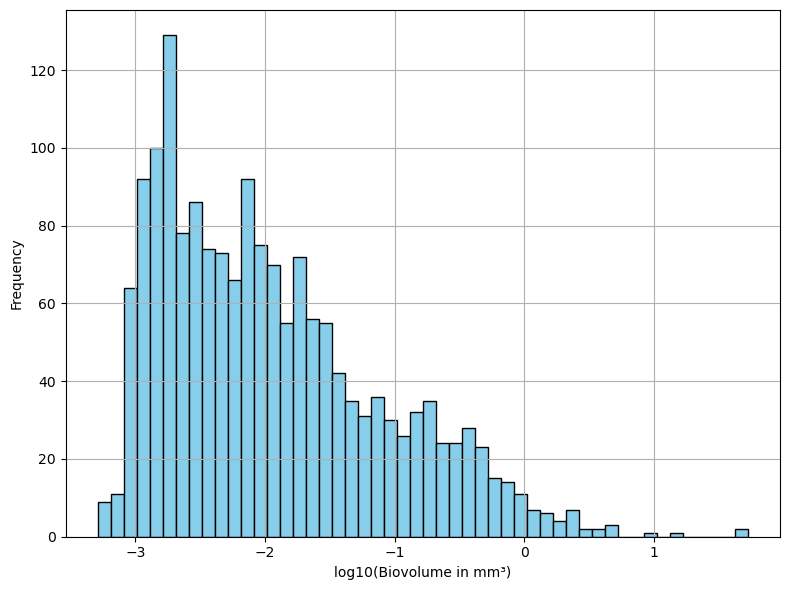

In [29]:
data = TZEX_all['biovolume_mm3'].dropna()
data = data[data > 0]

# Log-transform the data
log_data = np.log10(data)

# Plot histogram
plt.figure(figsize=(8, 6))
plt.hist(log_data, bins=50, color='skyblue', edgecolor='black')
plt.xlabel('log10(Biovolume in mm³)')
plt.ylabel('Frequency')
plt.grid(True)
plt.tight_layout()
plt.show()

# Create biovolume classes

In [31]:
bv_df = pd.read_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/biovolume_classes_median.csv', delimiter = ';')
bv_df

,width_bv,bv_median,ESD
0,0.000021,0.000123,61.715488
1,0.000025,0.000146,65.385282
2,0.000030,0.000174,69.273294
3,0.000036,0.000207,73.392498
4,0.000043,0.000246,77.756643
...,...,...,...
101,852.113093,4911.210218,21089.355153
102,1013.338953,5840.446135,22343.393468
103,1205.069892,6945.500099,23672.000782
104,1433.077690,8259.638135,25079.611198


In [32]:
# Paste your bv_median values here
bv_median = bv_df["bv_median"].astype(float).tolist()

# Convert to NumPy array
bv_median = np.array(bv_median)

# Compute class boundaries using geometric means
boundaries = np.sqrt(bv_median[:-1] * bv_median[1:])

# Build class ranges
class_lower_bounds = boundaries[:-1]
class_upper_bounds = boundaries[1:]
classes = list(zip(class_lower_bounds, class_upper_bounds))

# Create DataFrame for export or display
df_classes = pd.DataFrame(classes, columns=['Lower_Bound_mm3', 'Upper_Bound_mm3'])
df_classes.index += 1
df_classes.index.name = 'Class'

# Add string label column (e.g., "0.001–0.002")
df_classes['bv_classes'] = df_classes.apply(
    lambda row: f"{row['Lower_Bound_mm3']:.6g}-{row['Upper_Bound_mm3']:.6g}", axis=1
)

bv_classes = df_classes[['bv_classes']]#.astype(str)
bv_classes

,bv_classes
Class,
1,0.000134218-0.000159613
2,0.000159613-0.000189813
3,0.000189813-0.000225726
4,0.000225726-0.000268435
5,0.000268435-0.000319225
...,...
100,3787.06-4503.6
101,4503.6-5355.71
102,5355.71-6369.05


In [33]:
ranges = bv_classes['bv_classes'].tolist()

# Convert ranges to tuples of floats
bounds = [tuple(map(float, r.split('-'))) for r in ranges]

# Group into 11 bins
group_sizes = [5]*10 + [6]  # 10 groups of 5, last group of 6

merged_bins = []
labels = []
start_idx = 0

for size in group_sizes:
    group = bounds[start_idx:start_idx + size]
    merged_lower = group[0][0]
    merged_upper = group[-1][1]
    merged_bins.append((merged_lower, merged_upper))
    label = f"{merged_lower}-{merged_upper}"
    labels.append(label)
    start_idx += size

# Create bin edges
bin_edges = [merged_bins[0][0]] + [b[1] for b in merged_bins]
bin_edges

[0.000134218,
 0.000319225,
 0.00075925,
 0.00180581,
 0.00429497,
 0.0102152,
 0.024296,
 0.057786,
 0.137439,
 0.326887,
 0.777472,
 2.19902]

In [34]:
labels

['0.000134218-0.000319225',
 '0.000319225-0.00075925',
 '0.00075925-0.00180581',
 '0.00180581-0.00429497',
 '0.00429497-0.0102152',
 '0.0102152-0.024296',
 '0.024296-0.057786',
 '0.057786-0.137439',
 '0.137439-0.326887',
 '0.326887-0.777472',
 '0.777472-2.19902']

In [35]:
TZEX_all['bv_class_merged'] = pd.cut(
    TZEX_all['biovolume_mm3'],
    bins=bin_edges,
    labels=labels,
    include_lowest=True
)
TZEX_all


,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone,size_classes,minor_µm,minor_mm,major_µm,major_mm,biovolume_µm3,biovolume_mm3,bv_class_merged
0,33.540696,20230611-021733,APERO_C1_20230611-021845-1-1840,-73.891067,101.000576,40.222222,53.500000,-107.431763,1072.634722,32.751103,0.629040,2.643994,8.011938e+03,101.000576,2.696780,1.028456,1.091343,10.369217,25.548753,120.666667,37.000000,29.666667,54.000000,24.333333,3.166667,0.873285,0.750000,0.958333,464,-107.431763,-13.792357,19.978522,70.634841,-64.448676,not-living,APERO,North Atlantic,80.6-102,75.077280,0.075077,196.864930,0.196865,5.810106e+05,0.000581,0.000319225-0.00075925
1,-91.682424,20230619-033510,APERO_C2_20230619-033604-1-886,-1.087840,101.000576,32.333333,31.500000,90.594584,751.347464,27.410718,0.622343,2.862437,8.011938e+03,101.000576,2.651323,1.209351,1.190868,3.949334,12.384509,97.000000,32.000000,28.000000,37.000000,9.000000,3.250000,0.855803,0.687500,0.937500,278,90.594584,-17.043056,16.683448,67.273203,-67.632811,not-living,APERO,North Atlantic,80.6-102,88.282587,0.088283,193.546575,0.193547,7.898311e+05,0.000790,0.00075925-0.00180581
2,73.598156,20230618-104510,APERO_C2_20230618-104623-1-1253,14.729911,101.000576,51.916667,51.500000,-58.868245,468.561308,21.646277,0.616974,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,18.345278,32.470347,155.750000,50.750000,30.500000,74.500000,44.000000,3.000000,0.816497,0.750000,1.000000,307,-58.868245,-9.144133,11.746324,43.082010,-40.479818,not-living,APERO,North Atlantic,80.6-102,97.333333,0.097333,168.586279,0.168586,8.362652e+05,0.000836,0.00075925-0.00180581
3,55.670980,20230618-104510,APERO_C2_20230618-104726-1-2303,-12.886122,101.000576,55.333333,115.250000,-68.557102,468.561308,21.646277,0.616974,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,29.204182,51.272004,166.000000,40.250000,29.750000,96.000000,66.250000,3.000000,0.816497,0.750000,1.000000,307,-68.557102,-9.144133,11.746324,43.082010,-40.479818,not-living,APERO,North Atlantic,80.6-102,97.333333,0.097333,168.586279,0.168586,8.362652e+05,0.000836,0.00075925-0.00180581
4,-130.507237,20230617-214854,APERO_C2_20230617-214917-1-59,-47.636409,101.000576,72.166667,1.500000,82.870828,763.916503,27.639039,0.872297,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,24.572486,34.256622,216.500000,71.000000,43.500000,102.000000,58.500000,3.000000,0.816497,0.750000,1.000000,502,82.870828,-17.074307,16.354476,66.497650,-67.217481,not-living,APERO,North Atlantic,80.6-102,97.333333,0.097333,168.586279,0.168586,8.362652e+05,0.000836,0.00075925-0.00180581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1693,39.662255,20241123-010832,MBARI_2024_deep_20241123-011553-1-12818,165.157753,2026.318977,106.913805,421.272727,125.495498,2379.889918,48.784115,0.682748,129.252348,3.644171e+06,2026.318977,35.690958,23.585447,3.563078,38.015831,33.412966,81388.454545,115.818182,23.272727,181.545455,158.272727,774.454545,0.747243,0.577457,0.813269,407,125.495498,-29.664417,25.639862,108.596280,-112.620835,NaN,MBARI,East Pacific,1630-2050,1721.737624,1.721738,2605.439945,2.605440,4.044023e+09,4.044023,NaN
1694,42.478421,20241123-010832,MBARI_2024_deep_20241123-011558-1-12992,169.649491,2071.325803,60.670287,424.500000,127.171071,2379.889918,48.784115,0.682748,361.462987,6.765986e+06,2071.325803,50.534149,19.272838,4.511140,29.660832,41.810744,87157.625000,52.625000,26.250000,135.625000,109.375000,1518.000000,0.911555,0.523718,0.680143,407,127.171071,-29.664417,25.639862,108.596280,-112.620835,NaN,MBARI,East Pacific,2050-2580,1406.917164,

In [36]:
last_lower = float(labels[-1].split('-')[0])
max_bv = TZEX_all['biovolume_mm3'].max()
labels[-1] = f"{last_lower}-{max_bv}"

# Step 3: Create bin edges from the updated labels
bin_edges = [float(l.split('-')[0]) for l in labels]
bin_edges.append(max_bv)  # Ensure the final upper bound is included

# Step 4: Assign each row to a class based on biovolume
TZEX_all['bv_class_merged'] = pd.cut(
    TZEX_all['biovolume_mm3'],
    bins=bin_edges,
    labels=labels,
    include_lowest=True
)
TZEX_all['bv_class_merged'] = TZEX_all['bv_class_merged'].astype(str)
TZEX_all

,pred_poly,sequence,track_id,vertical_speed,size_um,meangrey,time,error,mse,rmse,r2,perim_px,area_um,esd_um,major_px,minor_px,perimmajor,stdgrey,cvgrey,intgrey,mediangrey,mingrey,maxgrey,rangegrey,area_convex,eccentricity,extent,solidity,track_count,corrected_by_poly,Q1,Q3,upper_bound,lower_bound,object_annotation_category,cruise,zone,size_classes,minor_µm,minor_mm,major_µm,major_mm,biovolume_µm3,biovolume_mm3,bv_class_merged
0,33.540696,20230611-021733,APERO_C1_20230611-021845-1-1840,-73.891067,101.000576,40.222222,53.500000,-107.431763,1072.634722,32.751103,0.629040,2.643994,8.011938e+03,101.000576,2.696780,1.028456,1.091343,10.369217,25.548753,120.666667,37.000000,29.666667,54.000000,24.333333,3.166667,0.873285,0.750000,0.958333,464,-107.431763,-13.792357,19.978522,70.634841,-64.448676,not-living,APERO,North Atlantic,80.6-102,75.077280,0.075077,196.864930,0.196865,5.810106e+05,0.000581,0.000319225-0.00075925
1,-91.682424,20230619-033510,APERO_C2_20230619-033604-1-886,-1.087840,101.000576,32.333333,31.500000,90.594584,751.347464,27.410718,0.622343,2.862437,8.011938e+03,101.000576,2.651323,1.209351,1.190868,3.949334,12.384509,97.000000,32.000000,28.000000,37.000000,9.000000,3.250000,0.855803,0.687500,0.937500,278,90.594584,-17.043056,16.683448,67.273203,-67.632811,not-living,APERO,North Atlantic,80.6-102,88.282587,0.088283,193.546575,0.193547,7.898311e+05,0.000790,0.00075925-0.00180581
2,73.598156,20230618-104510,APERO_C2_20230618-104623-1-1253,14.729911,101.000576,51.916667,51.500000,-58.868245,468.561308,21.646277,0.616974,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,18.345278,32.470347,155.750000,50.750000,30.500000,74.500000,44.000000,3.000000,0.816497,0.750000,1.000000,307,-58.868245,-9.144133,11.746324,43.082010,-40.479818,not-living,APERO,North Atlantic,80.6-102,97.333333,0.097333,168.586279,0.168586,8.362652e+05,0.000836,0.00075925-0.00180581
3,55.670980,20230618-104510,APERO_C2_20230618-104726-1-2303,-12.886122,101.000576,55.333333,115.250000,-68.557102,468.561308,21.646277,0.616974,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,29.204182,51.272004,166.000000,40.250000,29.750000,96.000000,66.250000,3.000000,0.816497,0.750000,1.000000,307,-68.557102,-9.144133,11.746324,43.082010,-40.479818,not-living,APERO,North Atlantic,80.6-102,97.333333,0.097333,168.586279,0.168586,8.362652e+05,0.000836,0.00075925-0.00180581
4,-130.507237,20230617-214854,APERO_C2_20230617-214917-1-59,-47.636409,101.000576,72.166667,1.500000,82.870828,763.916503,27.639039,0.872297,3.414214,8.011938e+03,101.000576,2.309401,1.333333,1.478398,24.572486,34.256622,216.500000,71.000000,43.500000,102.000000,58.500000,3.000000,0.816497,0.750000,1.000000,502,82.870828,-17.074307,16.354476,66.497650,-67.217481,not-living,APERO,North Atlantic,80.6-102,97.333333,0.097333,168.586279,0.168586,8.362652e+05,0.000836,0.00075925-0.00180581
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1693,39.662255,20241123-010832,MBARI_2024_deep_20241123-011553-1-12818,165.157753,2026.318977,106.913805,421.272727,125.495498,2379.889918,48.784115,0.682748,129.252348,3.644171e+06,2026.318977,35.690958,23.585447,3.563078,38.015831,33.412966,81388.454545,115.818182,23.272727,181.545455,158.272727,774.454545,0.747243,0.577457,0.813269,407,125.495498,-29.664417,25.639862,108.596280,-112.620835,NaN,MBARI,East Pacific,1630-2050,1721.737624,1.721738,2605.439945,2.605440,4.044023e+09,4.044023,0.777472-52.624647797022895
1694,42.478421,20241123-010832,MBARI_2024_deep_20241123-011558-1-12992,169.649491,2071.325803,60.670287,424.500000,127.171071,2379.889918,48.784115,0.682748,361.462987,6.765986e+06,2071.325803,50.534149,19.272838,4.511140,29.660832,41.810744,87157.625000,52.625000,26.250000,135.625000,109.375000,1518.000000,0.911555,0.523718,0.680143,407,127.171071,-29.664417,25.639862,108.596280,-112.620835,NaN,MBARI,East Pacifi

In [37]:
TZEX_all = TZEX_all.sort_values(by='biovolume_mm3')
print(TZEX_all['bv_class_merged'].unique())

['0.000319225-0.00075925' '0.00075925-0.00180581' '0.00180581-0.00429497'
 '0.00429497-0.0102152' '0.0102152-0.024296' '0.024296-0.057786'
 '0.057786-0.137439' '0.137439-0.326887' '0.326887-0.777472'
 '0.777472-52.624647797022895']


# Save the biovolume classes

In [38]:
bv_classes_merged = TZEX_all[['bv_class_merged']].drop_duplicates()

In [39]:
bv_classes_merged.to_csv('/home/aaccardo/these_alex/Papers/Rising_stars/Data/bv_classes_merged.csv', index = False)

In [40]:
desc = TZEX_all[TZEX_all['corrected_by_poly'] >= 0]
desc = desc.sort_values(by='biovolume_mm3')
asc = TZEX_all[TZEX_all['corrected_by_poly'] < 0]
asc = asc.sort_values(by='biovolume_mm3')

# **Compute the number of particles for each biovolume class for ascending and descending categories**

In [41]:
# for descending ones 
nb_part_desc = desc.groupby('bv_class_merged').size().reset_index(name='desc_count')
nb_part_desc['lower_bound'] = nb_part_desc['bv_class_merged'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_desc = nb_part_desc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_desc

,bv_class_merged,desc_count
0,0.000319225-0.00075925,11
1,0.00075925-0.00180581,207
2,0.00180581-0.00429497,205
3,0.00429497-0.0102152,157
4,0.0102152-0.024296,142
5,0.024296-0.057786,117
6,0.057786-0.137439,102
7,0.137439-0.326887,96
8,0.326887-0.777472,72
9,0.777472-52.624647797022895,42


In [42]:
# for ascending ones 
nb_part_asc = asc.groupby('bv_class_merged').size().reset_index(name='asc_count')
nb_part_asc['lower_bound'] = nb_part_asc['bv_class_merged'].str.extract(r'([\d\.]+)').astype(float)
# Sort by the lower bound
nb_part_asc = nb_part_asc.sort_values(by='lower_bound').drop(columns=['lower_bound'])
nb_part_asc

,bv_class_merged,asc_count
0,0.000319225-0.00075925,5
1,0.00075925-0.00180581,104
2,0.00180581-0.00429497,125
3,0.00429497-0.0102152,130
4,0.0102152-0.024296,98
5,0.024296-0.057786,47
6,0.057786-0.137439,16
7,0.137439-0.326887,9
8,0.326887-0.777472,5
9,0.777472-52.624647797022895,8


In [43]:
# merge both
nb_part_tot_all_TZEX = pd.merge(nb_part_desc, nb_part_asc, on = 'bv_class_merged')
nb_part_tot_all_TZEX['nb_part_tot'] = nb_part_tot_all_TZEX['desc_count'] + nb_part_tot_all_TZEX['asc_count']
nb_part_tot_all_TZEX['asc_prop_%'] = (nb_part_tot_all_TZEX['asc_count']*100)/nb_part_tot_all_TZEX['nb_part_tot']
nb_part_tot_all_TZEX['desc_prop_%'] = (nb_part_tot_all_TZEX['desc_count']*100)/nb_part_tot_all_TZEX['nb_part_tot']
nb_part_tot_all_TZEX = nb_part_tot_all_TZEX[(nb_part_tot_all_TZEX['nb_part_tot'] >= 10)]
nb_part_tot_all_TZEX

,bv_class_merged,desc_count,asc_count,nb_part_tot,asc_prop_%,desc_prop_%
0,0.000319225-0.00075925,11,5,16,31.250000,68.750000
1,0.00075925-0.00180581,207,104,311,33.440514,66.559486
2,0.00180581-0.00429497,205,125,330,37.878788,62.121212
3,0.00429497-0.0102152,157,130,287,45.296167,54.703833
4,0.0102152-0.024296,142,98,240,40.833333,59.166667
5,0.024296-0.057786,117,47,164,28.658537,71.341463
6,0.057786-0.137439,102,16,118,13.559322,86.440678
7,0.137439-0.326887,96,9,105,8.571429,91.428571
8,0.326887-0.777472,72,5,77,6.493506,93.506494
9,0.777472-52.624647797022895,42,8,50,16.000000,84.000000


In [44]:
nb_part_tot_all_TZEX['bv_class_merged'].unique().tolist()

['0.000319225-0.00075925',
 '0.00075925-0.00180581',
 '0.00180581-0.00429497',
 '0.00429497-0.0102152',
 '0.0102152-0.024296',
 '0.024296-0.057786',
 '0.057786-0.137439',
 '0.137439-0.326887',
 '0.326887-0.777472',
 '0.777472-52.624647797022895']

# **Generate the figure**

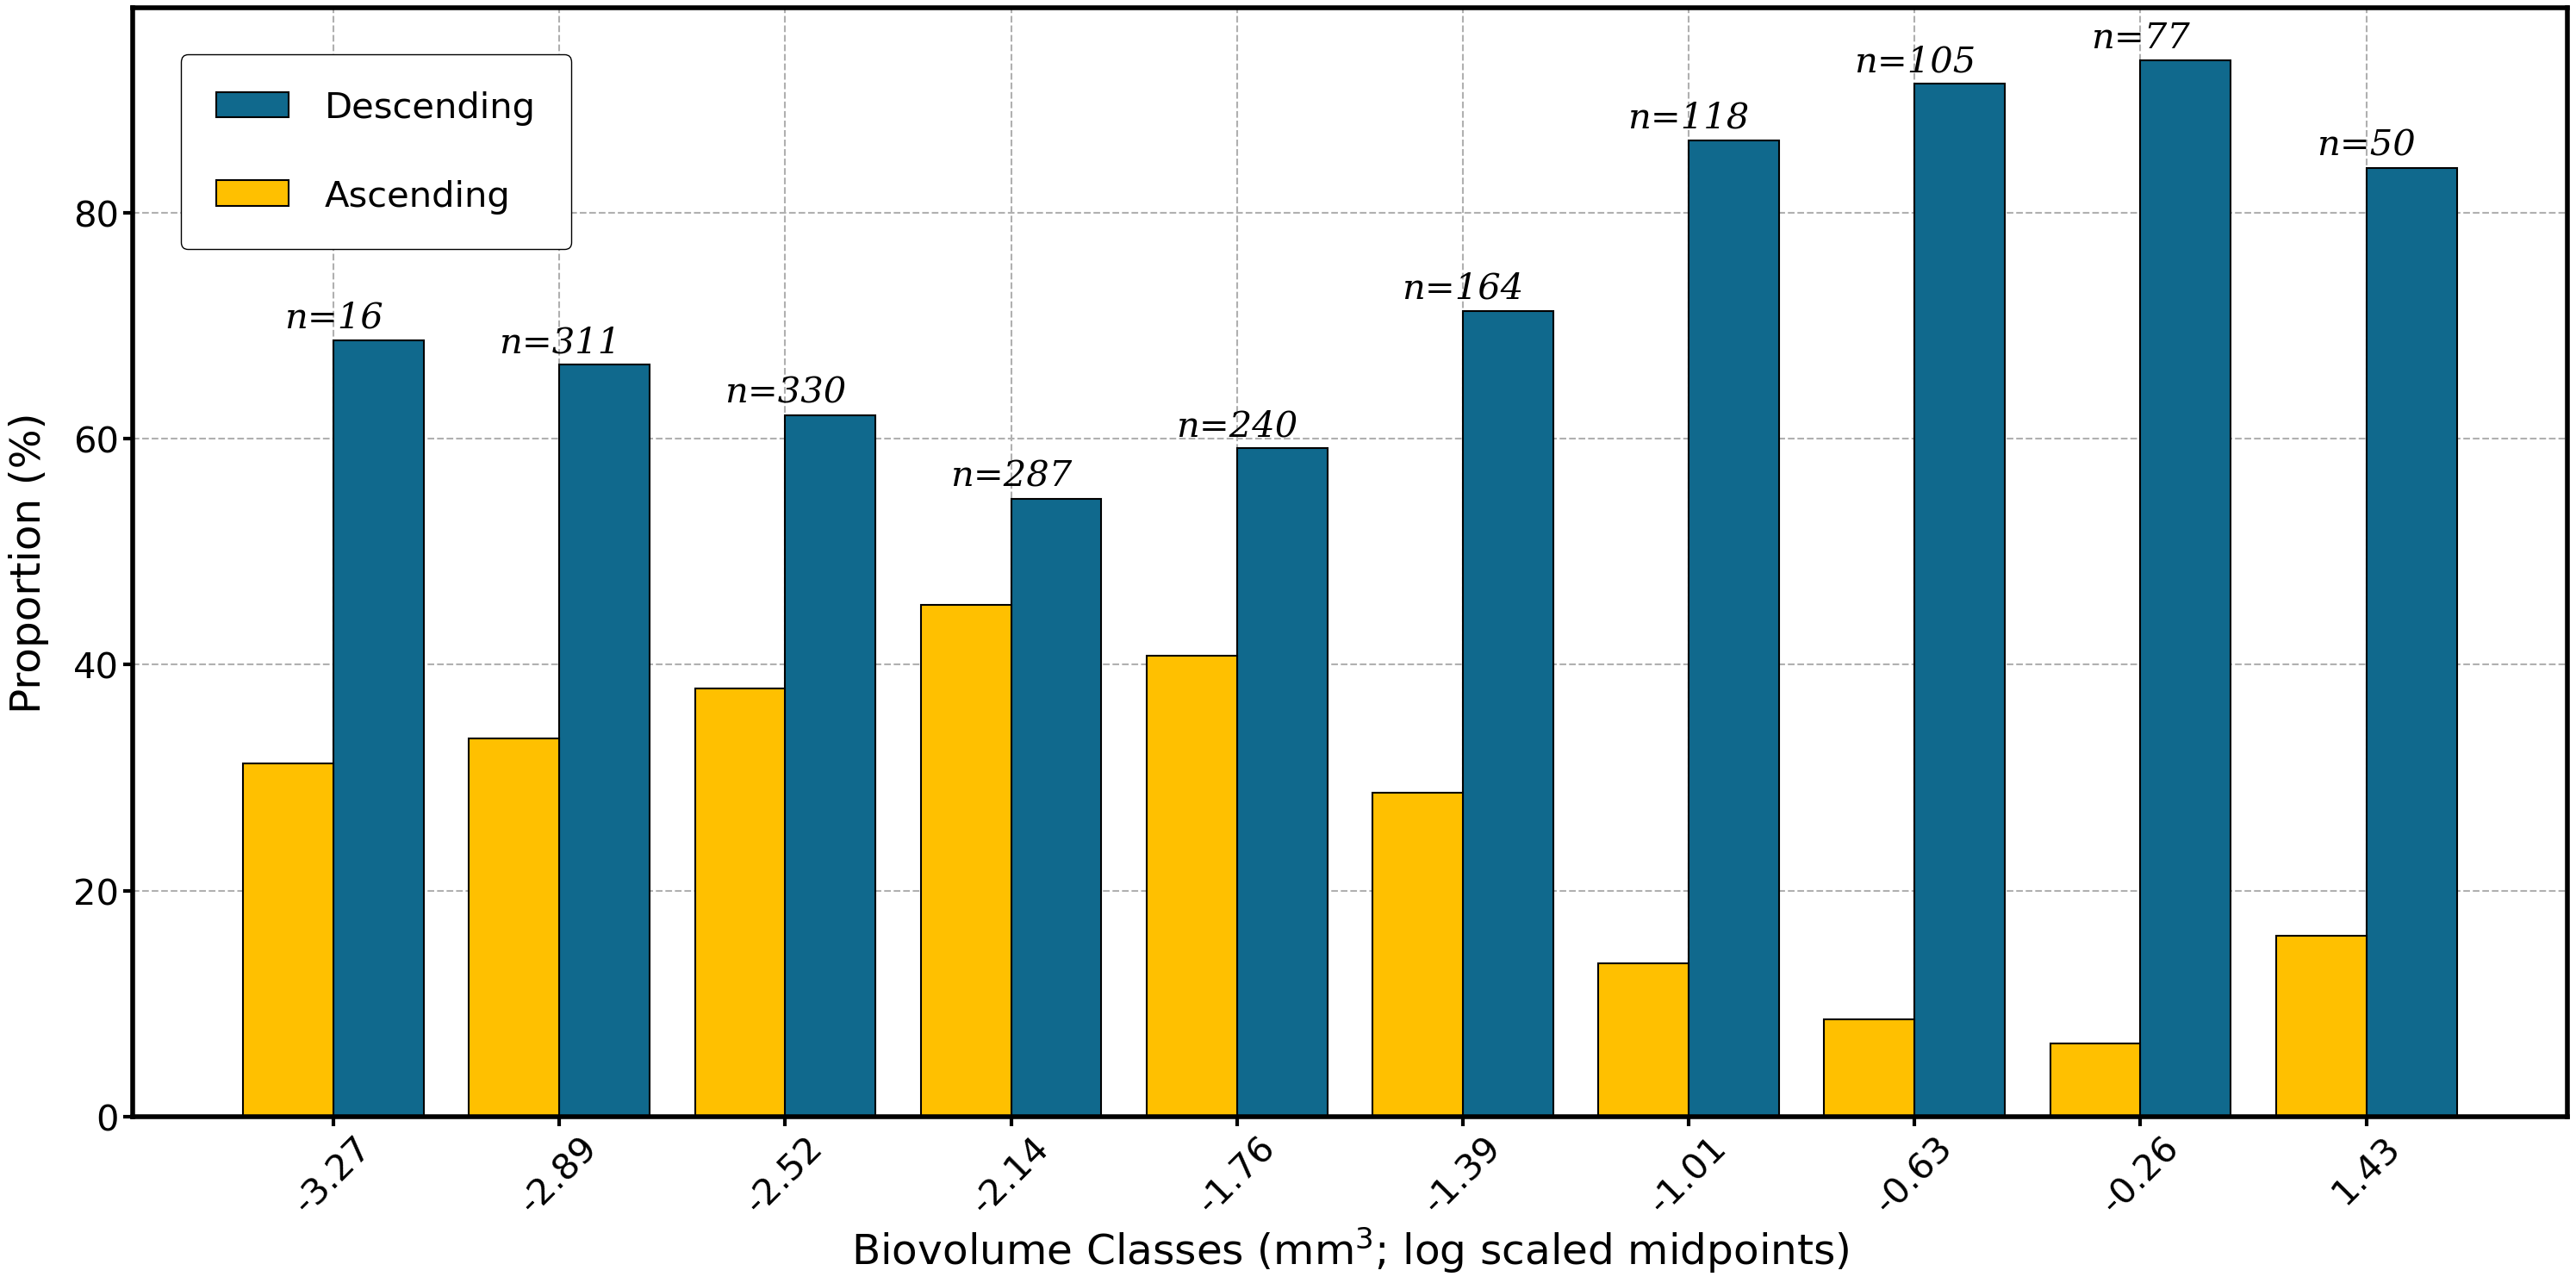

In [54]:
# Create the merged figure
fig, ax = plt.subplots(1, 1, figsize=(30, 15))


# --- Figure 2 ---
bv_classes = ['0.000319225-0.00075925',  
 '0.00075925-0.00180581',
 '0.00180581-0.00429497',
 '0.00429497-0.0102152',
 '0.0102152-0.024296',
 '0.024296-0.057786',
 '0.057786-0.137439',
 '0.137439-0.326887',
 '0.326887-0.777472',
 '0.777472-52.624647797022895']

log_midpoints = []
for cls in bv_classes:
    lower, upper = map(float, cls.split('-'))
    midpoint = (lower + upper) / 2
    log_midpoint = np.log10(midpoint)
    log_midpoints.append(round(log_midpoint, 2))  # round for readability

# Step 2: Convert to strings for x-tick labels
log_labels = [f"{m}" for m in log_midpoints]

# X-axis positioning
x = np.arange(len(bv_classes))
bar_width = 0.4

# Plot bars (same as before)
ax.grid(True, which="both", ls="--", linewidth=1.5, zorder=1)

desc_bars = ax.bar(x + bar_width / 2, nb_part_tot_all_TZEX['desc_prop_%'], width=bar_width,
                   label='Descending', color='#10698D', edgecolor='black', linewidth=1.5, zorder=2)
asc_bars = ax.bar(x - bar_width / 2, nb_part_tot_all_TZEX['asc_prop_%'], width=bar_width,
                  label='Ascending', color='#FFC000', edgecolor='black', linewidth=1.5, zorder=2)

# Axis labels
size = 35
ax.set_xlabel('Biovolume Classes (mm$^3$; log scaled midpoints)', fontsize=size)
ax.set_ylabel('Proportion (%)', fontsize=size, labelpad=20)
ax.set_xticks(x)
ax.set_xticklabels(log_labels, rotation=45, ha='center')
ax.tick_params(axis='y', labelsize=size-5, length=8, width=3)
ax.tick_params(axis='x', labelsize=size-5, length=8, width=3)

# Annotations
for i, total in enumerate(nb_part_tot_all_TZEX['nb_part_tot']):
    ax.text(x[i], max(desc_bars[i].get_height(), asc_bars[i].get_height()) + 2,
            f'n={str(total)}', fontsize=30, ha='center', va='center',
            fontstyle='italic', fontfamily='serif')

# Legend and styling
ax.legend(loc='center', bbox_to_anchor=(0.1, 0.87), fontsize=30, labelspacing=1.5, markerscale=1, handletextpad=1, 
          borderpad=1, edgecolor='black', frameon=True, framealpha=1, fancybox=True, shadow=False, ncol=1)



for spine in ax.spines.values():
    spine.set_linewidth(4)

# Hide the by default frame 
axs = axs.flatten()
for i in [3, 4]:  # Apply the same adjustments for axs[2] and axs[3]
    for spine in axs[i].spines.values():
        spine.set_visible(False)
    axs[i].set_facecolor('white')
    axs[i].tick_params(axis='both', which='both', length=0)  # Hides ticks
    axs[i].set_xticklabels([])  # Hides x-axis labels
    axs[i].set_yticklabels([])  # Hides y-axis labels

for i in [4, 5]:  # Apply the same adjustments for axs[2] and axs[3]
    for spine in axs[i].spines.values():
        spine.set_visible(False)
    axs[i].set_facecolor('white')
    axs[i].tick_params(axis='both', which='both', length=0)  # Hides ticks
    axs[i].set_xticklabels([])  # Hides x-axis labels
    axs[i].set_yticklabels([])  # Hides y-axis labels

plt.tight_layout()
plt.subplots_adjust(hspace=0.2)
plt.savefig('/home/aaccardo/these_alex/Papers/Rising_stars/Figure_S8/Figure_S8.png', dpi = 300)
plt.show()